# JEPA latent model — wolf–rabbit–grass evaluation

Companion notebook for the decoder-free model in `src/jepa_control/`, pointed at the
**wolf cull** ABM (`data/wolf_rabbit_grass_images_cull03/` by default). Same three questions as the rabbit
notebook:

1. **Did it avoid collapse?** VICReg variance / covariance and participation ratio.
2. **Is it interpretable?** Post-hoc linear readout `z -> macrostates` (especially
   `wolf_count`, the controlled population).
3. **Can you steer it?** Dose/step response, then closed-loop MPC on the true wolf ABM.

The actuator removes **wolves** (not rabbits). The default control objective here is
tracking `wolf_count`. The default predictor is linear (`z' = A z + B u + c`); the
post-hoc `ls_linear` operator is the optimality check for that choice.


In [1]:
from pathlib import Path
import json

from koopman_control.data.wolf_rabbit_grass import WolfRabbitGrassConfig
from koopman_control.paths import PROJECT_ROOT, output_root

OUTPUT_ROOT = output_root()

# Point this at a run produced by `python -m jepa_control.train --dataset ...wolves...`.
RUN_DIR = Path(OUTPUT_ROOT / "jepa_training/jepa-wolves-cull03-h20-mlp")

run_cfg = json.loads((RUN_DIR / "config.json").read_text())
# Prefer the dataset this run was trained on (avoids path drift vs wolf_dataset_path()).
# Config stores a repo-relative path; resolve against PROJECT_ROOT so this works
# when the kernel cwd is notebooks/ (or anything else).
_dataset = Path(run_cfg["dataset"])
DATASET = _dataset if _dataset.is_absolute() else (PROJECT_ROOT / _dataset).resolve()
if not DATASET.exists():
    raise FileNotFoundError(f"Dataset not found: {DATASET}")

checkpoints = sorted((RUN_DIR / "checkpoints").glob("best-*.ckpt"))
if not checkpoints:
    raise FileNotFoundError(f"No best-*.ckpt under {RUN_DIR / 'checkpoints'}")
CKPT = max(checkpoints, key=lambda p: p.stat().st_mtime)
METRICS = RUN_DIR / "logs/metrics.csv"
if not METRICS.exists():
    raise FileNotFoundError(f"Metrics not found: {METRICS}")

# Match the training horizon so scorecard numbers line up with logged metrics.
SCORE_HORIZON = int(run_cfg.get("horizon", 20))
# Runs used to fit the readout and probes.
N_PROBE_TRAIN = 40

# Controlled macrostate and ABM identity used throughout.
CONTROL_OBS = "wolf_count"
ABM = "wolf_rabbit_grass"
INITIAL_RABBITS = 120
INITIAL_WOLVES = 16

# Closed-loop / dose-response plant must match the generator used for DATASET.
manifest_path = DATASET.parent / "manifest.json"
_manifest = json.loads(manifest_path.read_text())
_cull_eff = float(_manifest.get("config", {}).get("culling_effectiveness", 0.03))
_cull_delay = float(_manifest.get("config", {}).get("cull_delay_fraction", 0.5))
ABM_CFG = WolfRabbitGrassConfig(
    culling_effectiveness=_cull_eff,
    cull_delay_fraction=_cull_delay,
)

print("dataset    :", DATASET)
print("checkpoint :", CKPT)
print("metrics    :", METRICS)
print("control obs:", CONTROL_OBS)
print(
    f"ABM cull   : effectiveness={ABM_CFG.culling_effectiveness}  "
    f"delay={ABM_CFG.cull_delay_fraction}"
)

# MPC: cross-entropy planner over the learned latent model.
# control_cost penalizes sum of u^2 over the plan (per planned step).
MPC_CONTROL_COST = 1.0
print(
    f"predictor  : {run_cfg.get('predictor')}  "
    f"latent_dim={run_cfg.get('latent_dim')}  "
    f"horizon={SCORE_HORIZON}"
)


dataset    : /Users/jacobevarts/BagheriLab/abm-control/data/wolf_rabbit_grass_images_cull03/dataset.h5
checkpoint : /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-wolves-cull03-h20-mlp/checkpoints/best-000-2138-0.286106.ckpt
metrics    : /Users/jacobevarts/BagheriLab/abm-control/outputs/jepa_training/jepa-wolves-cull03-h20-mlp/logs/metrics.csv
control obs: wolf_count
ABM cull   : effectiveness=0.03  delay=0.5
predictor  : residual_mlp  latent_dim=8  horizon=20


## 1. Load and score

One cell does all the expensive work (encoding the held-out splits, fitting the readout
and probes, sweeping the wolf simulator for dose-response) so every plot below is instant.

The readout is fit on **train** encodings and scored on **val**. The encoder never saw
the observables during training, so held-out R² is a genuine test of what self-supervision
discovered — especially whether `wolf_count` is linearly available for the MPC cost.


In [2]:
%matplotlib inline
import numpy as np

from jepa_control import evaluate as ev
from jepa_control import plots as jp

model = ev.load_model(CKPT)
val = ev.load_split_trajectories(DATASET, "val")
test = ev.load_split_trajectories(DATASET, "test")
probe_train = ev.load_split_trajectories(DATASET, "train", N_PROBE_TRAIN)

# Encode once, reuse everywhere.
enc = ev.encode_all(model, val)
enc_train = ev.encode_all(model, probe_train)

# The readout is the decoder's replacement: fit on train, scored on held-out val.
readout = ev.fit_readout(enc_train)
r2_val = ev.readout_r2(readout, enc)

fitted = ev.fit_latent_linear(model, enc)  # linearity diagnostic only
herr = ev.horizon_errors(model, enc, fitted)
pca = ev.latent_pca(enc)
probe = ev.linear_probe(model, probe_train, val)
skill = ev.readout_rollout_skill(model, enc, readout, obs_name=CONTROL_OBS)
dose = ev.dose_response(
    model,
    readout,
    obs_name=CONTROL_OBS,
    abm=ABM,
    cfg=ABM_CFG,
    steps=100,
    seeds=(0, 1, 2),
    initial_rabbits=INITIAL_RABBITS,
    initial_wolves=INITIAL_WOLVES,
)

print(f"latent dim    : {model.latent_dim}   train horizon: {model.hparams.horizon}")
print(f"readout loss  : w_readout={model.hparams.w_readout} "
      f"({'anchored' if model.hparams.w_readout > 0 else 'pure JEPA'})")
print(f"held-out runs : {len(val)} val / {len(test)} test, {enc['z'].shape[1]} frames each")
print(f"obs names     : {list(enc['obs_names'])}")
print()
print(ev.format_scorecard(ev.scorecard(
    model=model, herr=herr, probe=probe, pca=pca, readout_r2_test=r2_val,
    rollout_skill=skill, dose=dose, fitted=fitted, horizon=SCORE_HORIZON,
    primary_obs=CONTROL_OBS,
)))


latent dim    : 8   train horizon: 20
readout loss  : w_readout=0.0 (pure JEPA)
held-out runs : 126 val / 126 test, 201 frames each
obs names     : ['rabbit_count', 'wolf_count', 'grass_count', 'grass_frac', 'rabbit_centroid_x', 'rabbit_centroid_y', 'rabbit_spread', 'wolf_centroid_x', 'wolf_centroid_y', 'wolf_spread']

metric                                 value  status  note
--------------------------------------------------------------
prediction skill @ h=20               +0.335  [warn]  vs +0.188 for the persistence baseline
beats persistence?                       yes  [ ok ]  a model that loses to a frozen latent learned no dynamics
no collapse (dims in use)            7.6 / 8  [ ok ]  participation ratio; 8 components cover 95%
wolf_count readout R^2                +0.903  [ ok ]  held-out; this is what the MPC cost is written in
control legible in latent             +0.089  [FAIL]  R^2 predicting the applied u from z alone
macrostate rollout corr               +0.386  [FAIL]  

## 2. What control does the data actually contain?

Before trusting any dose-response plot, check that the held-out split actually spans
cull levels and excitation types. On this ABM, `u` culls **wolves**.


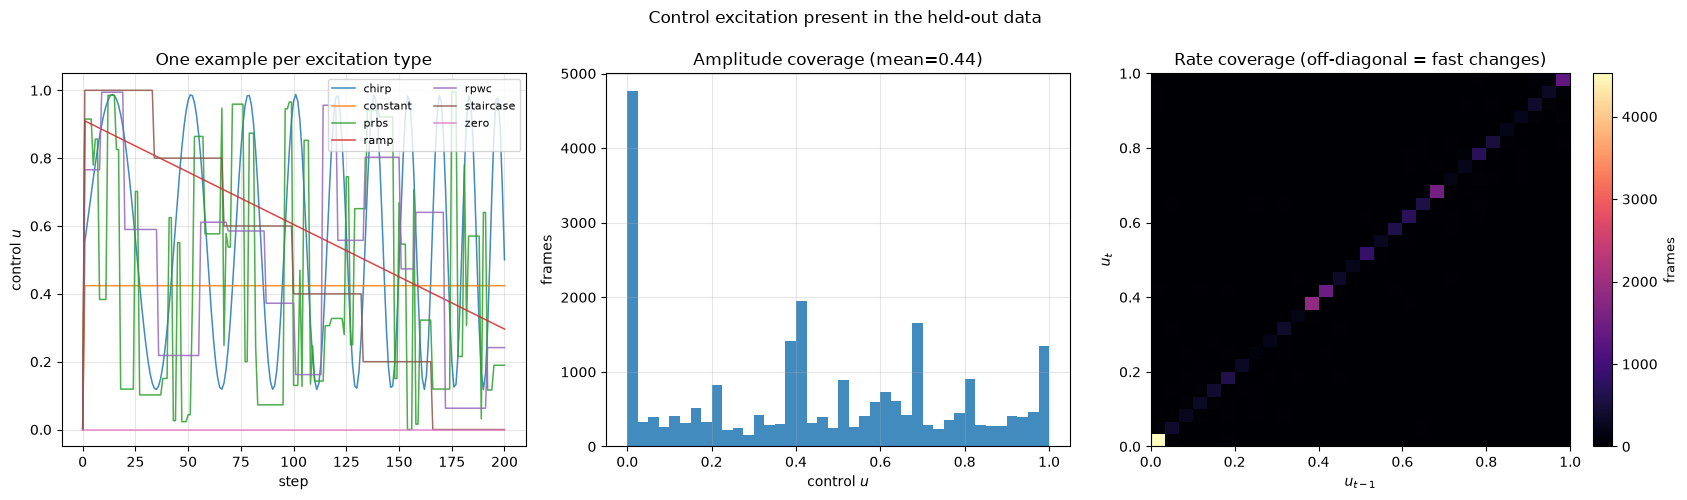

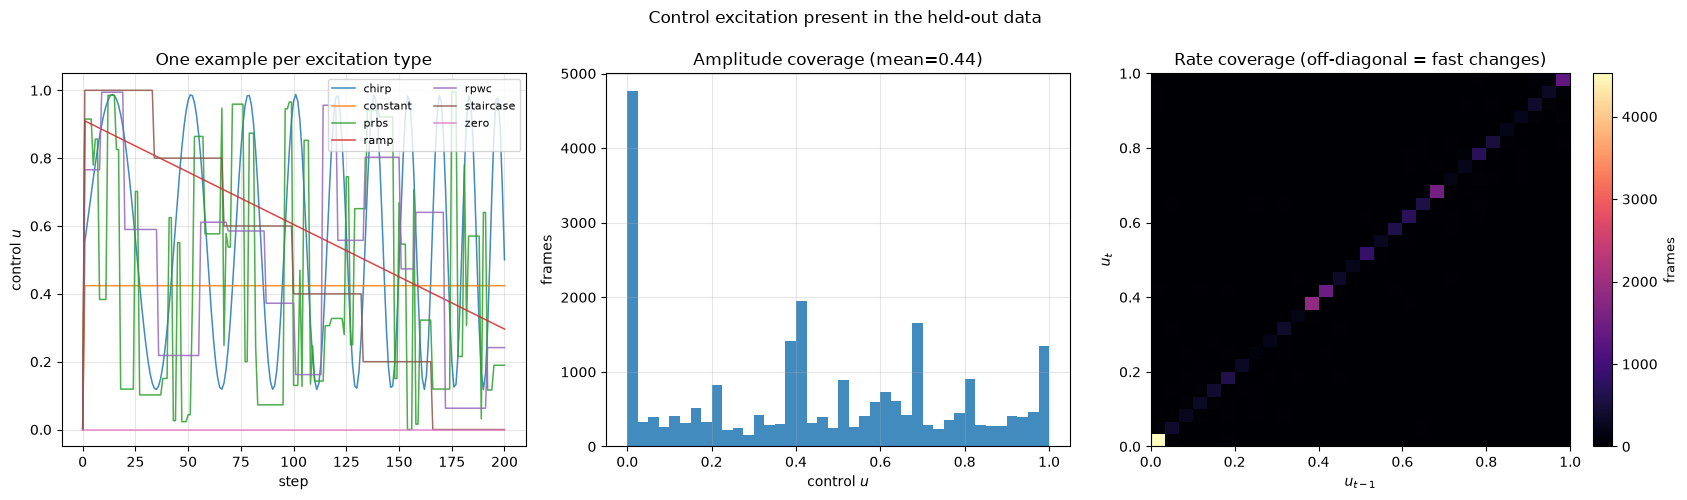

In [3]:
jp.fig_control_coverage(val)

## 3. Training curves

The middle panel is the one unique to this model. `vic_var` near 0 means every latent
dimension sits above the variance floor; if it climbs toward 1 the representation is
collapsing. The participation ratio on the right is the subtler check — it catches a
latent quietly shrinking into a low-dimensional subspace while the loss still improves.

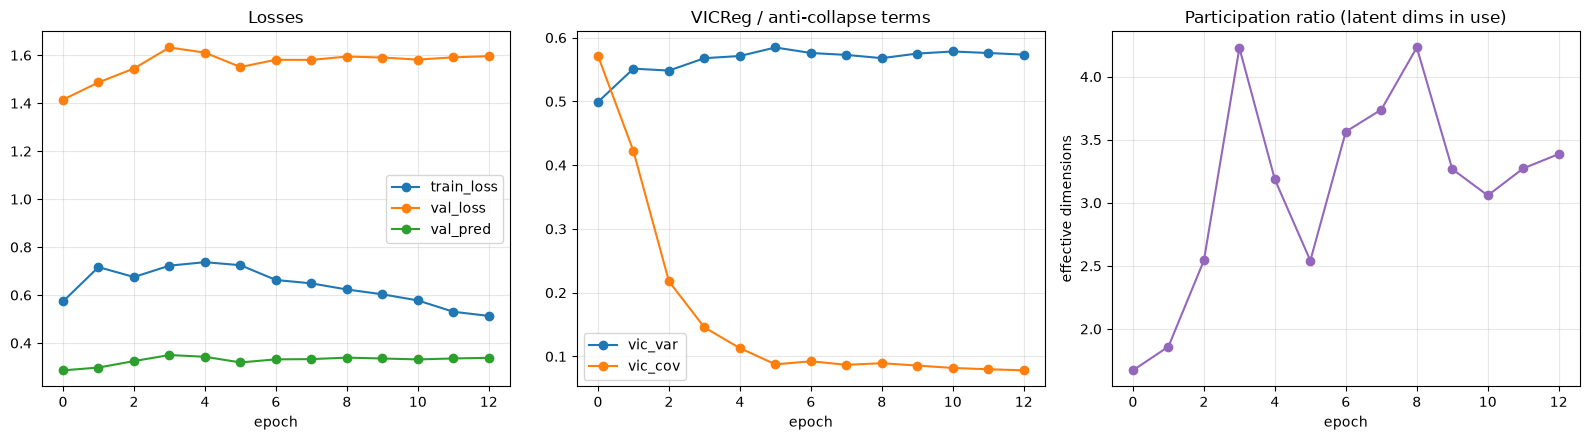

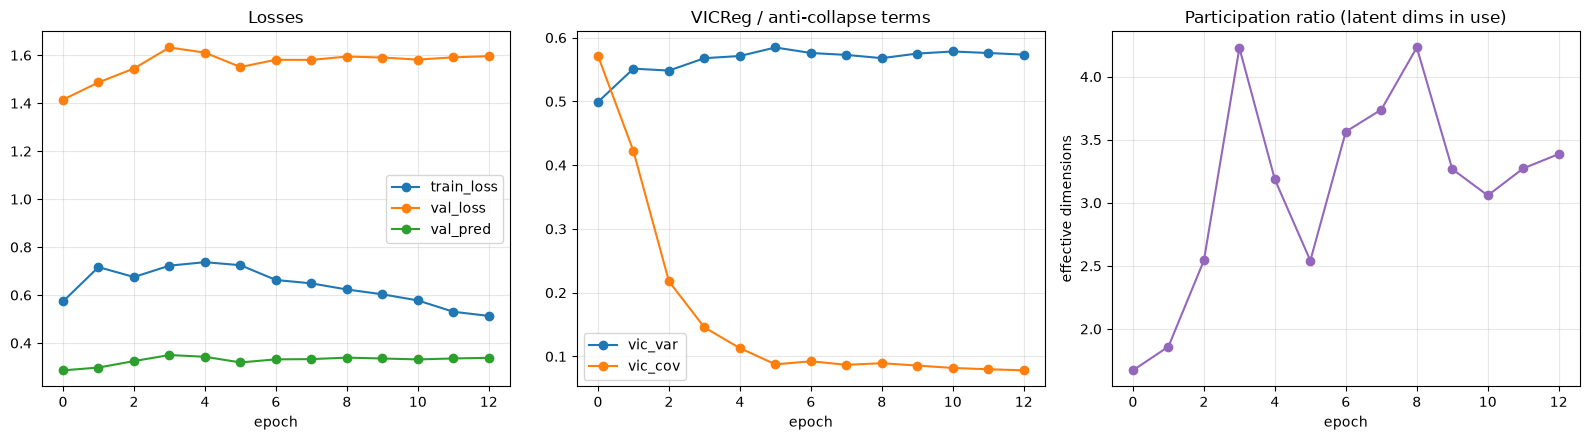

In [4]:
jp.fig_learning_curves(METRICS)

## 4. Prediction accuracy, against baselines

`persistence` (freeze the initial latent) is the floor — losing to it means no dynamics
were learned. `ls_linear` is the best least-squares linear operator in this same latent.
With the default linear predictor, `full` should sit on top of `ls_linear`; a visible
gap means the trained `A`/`B` are under-optimized relative to what the latent supports.
For the `residual_mlp` ablation, that same gap instead measures what the nonlinearity
is buying.

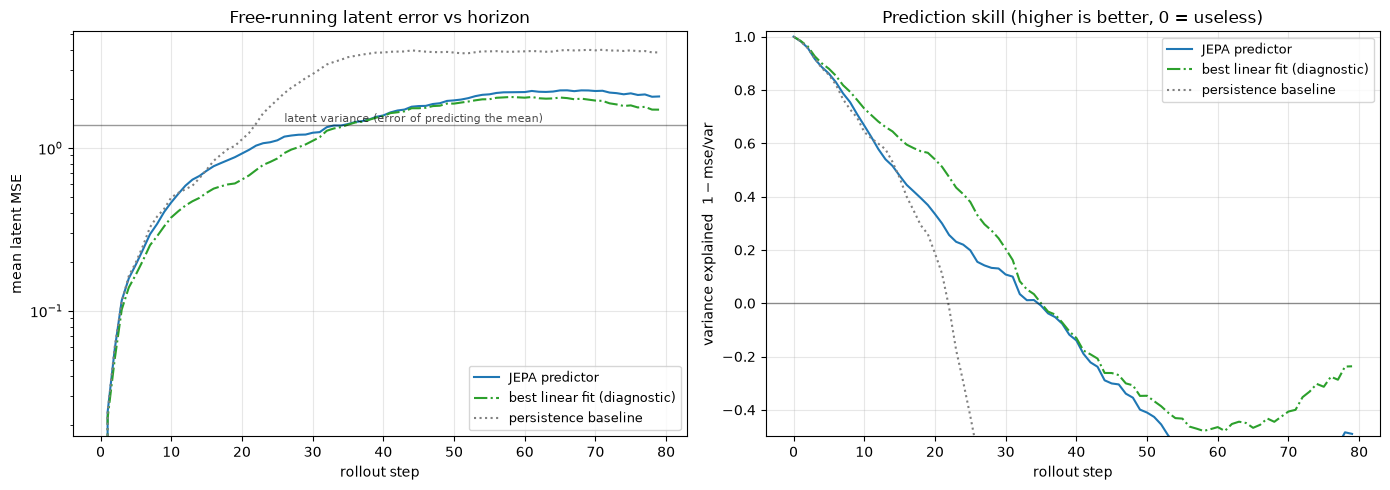

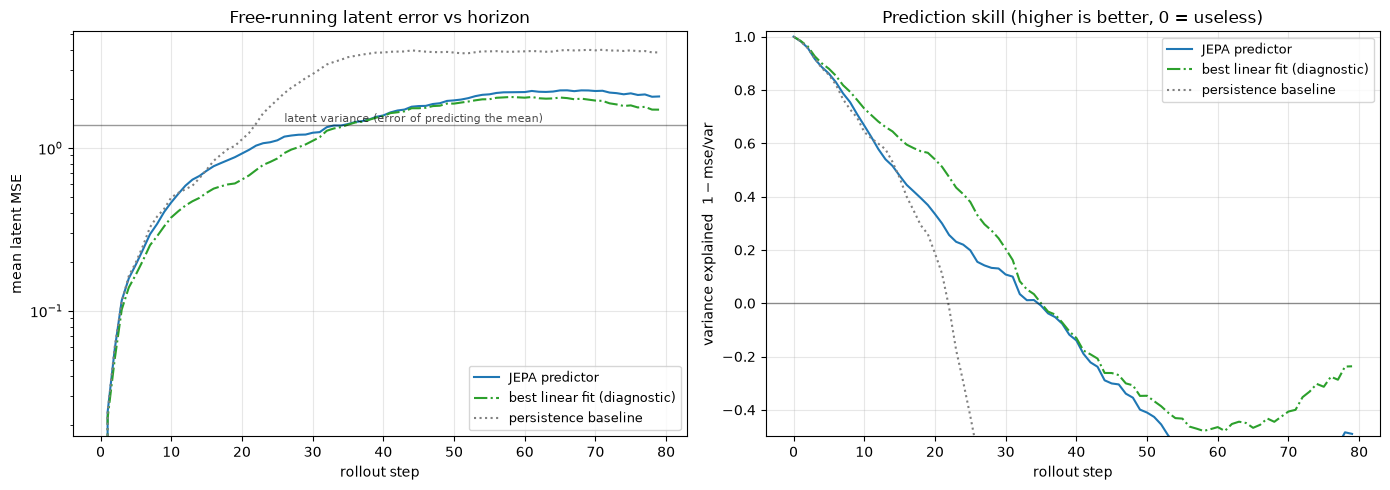

In [5]:
jp.fig_horizon_errors(herr, max_step=80)

## 5. Is the latent uncollapsed and structured?

PCA of encoded frames, colored by wolf/rabbit counts, control, and time. Salt-and-pepper
coloring means that quantity is absent or buried; a smooth gradient means it lives in the
dominant directions MPC needs.


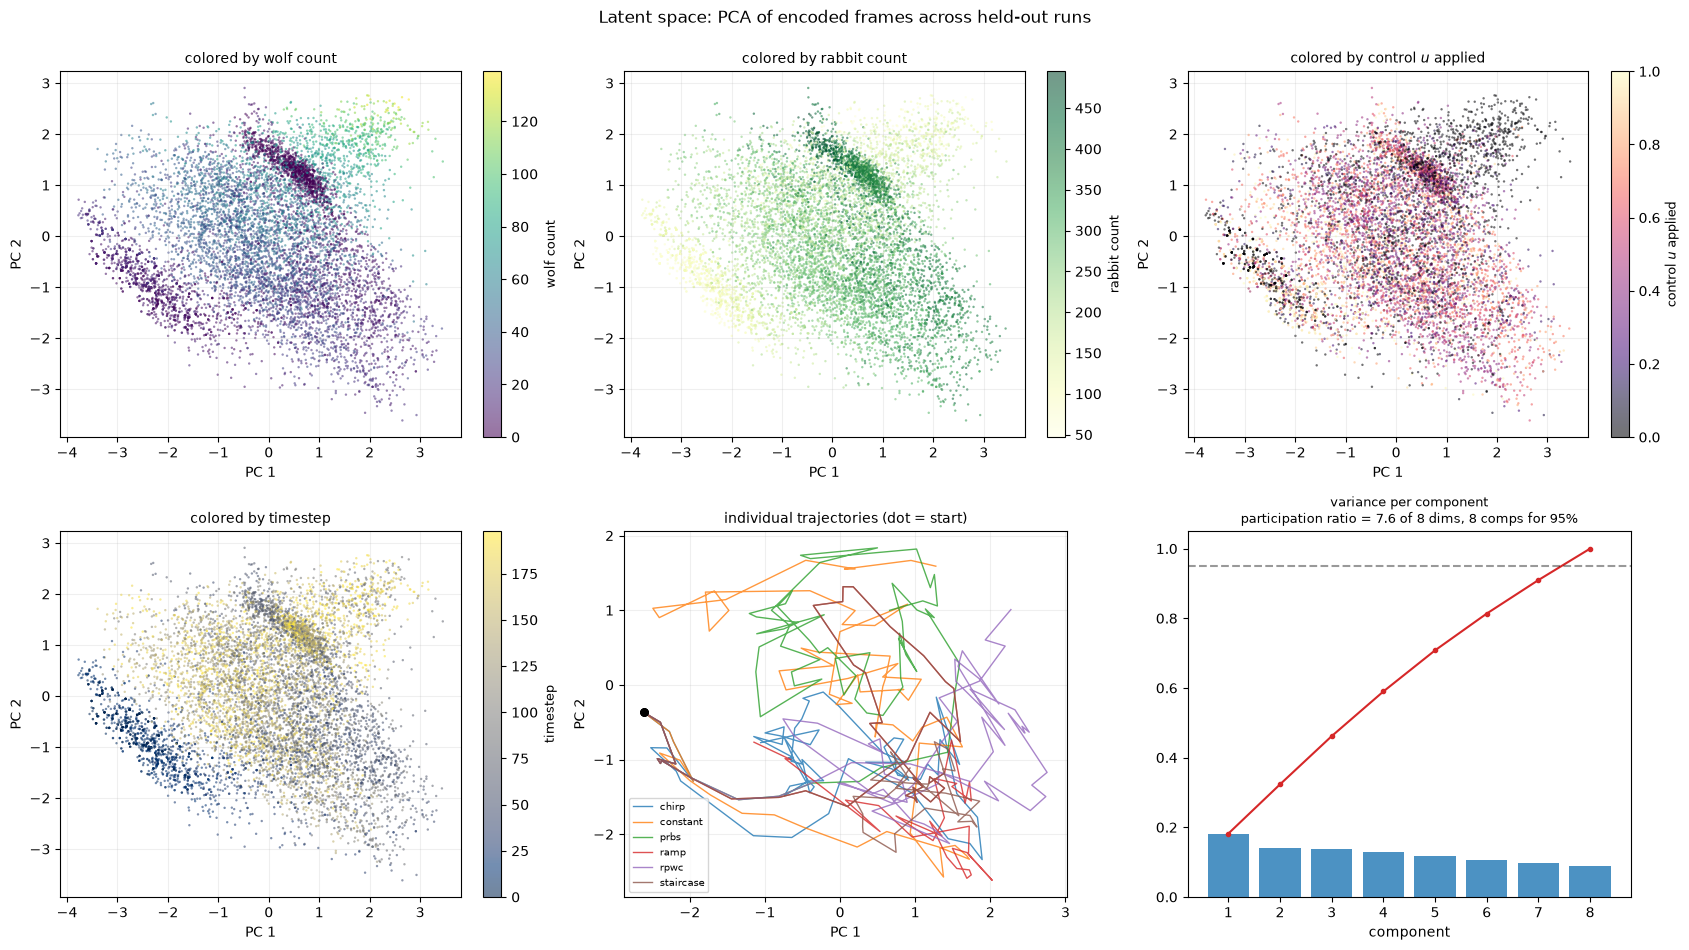

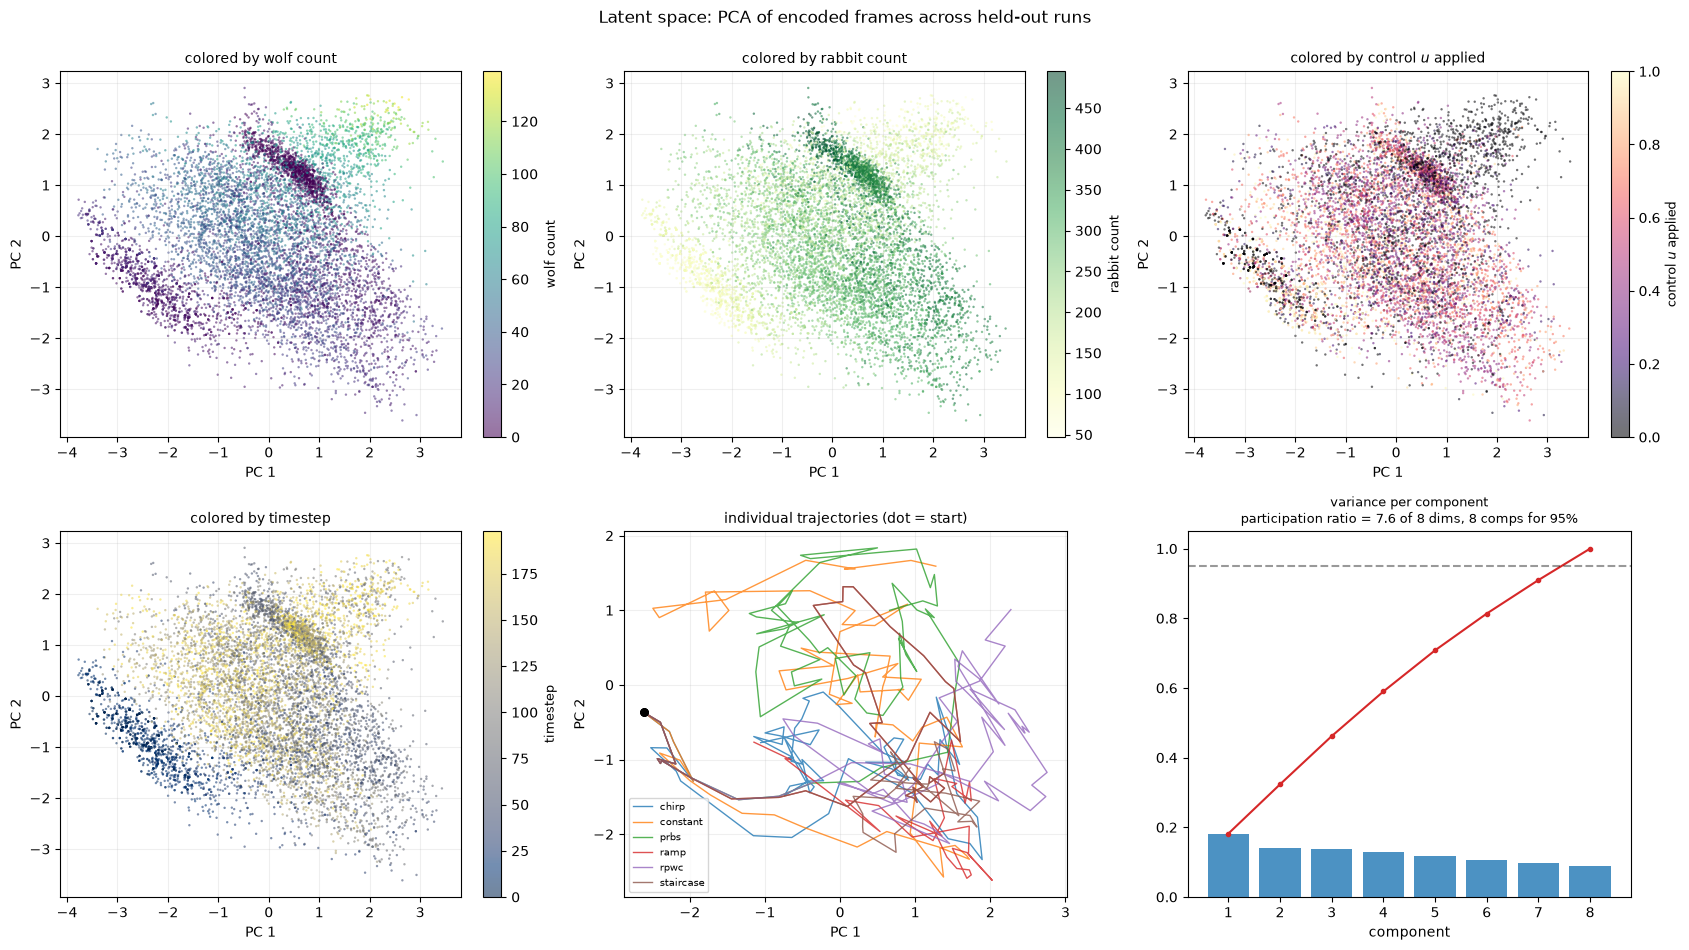

In [6]:
jp.fig_latent_pca(pca, stride=3, n_traj_lines=6)

### 5b. What can be linearly read out of the latent?

`wolf_count` near 1 licenses writing the MPC cost in readout space. `u_applied` tests
whether the encoder registers the wolf cull at all.


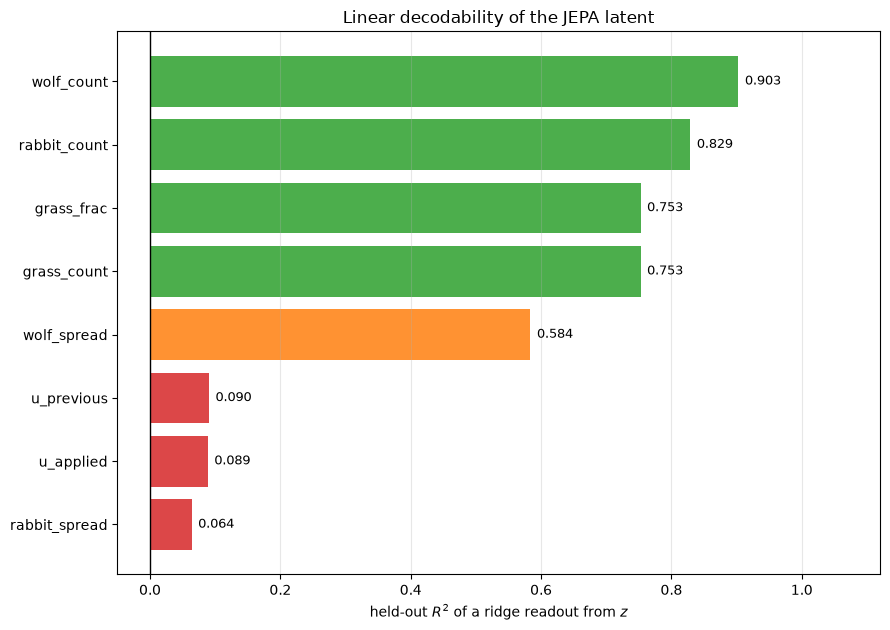

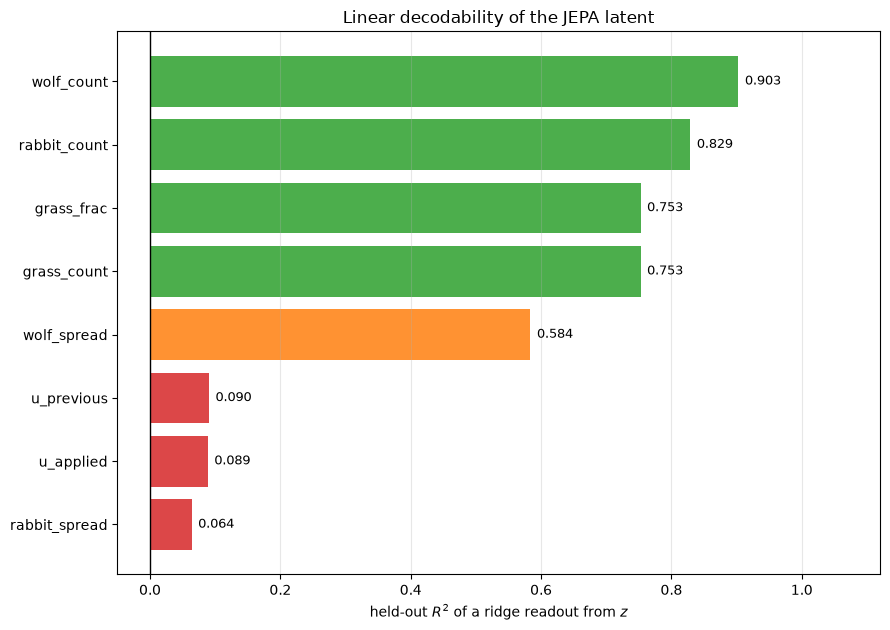

In [7]:
jp.fig_latent_probe(probe)

### 5c. Individual latent dimensions over time

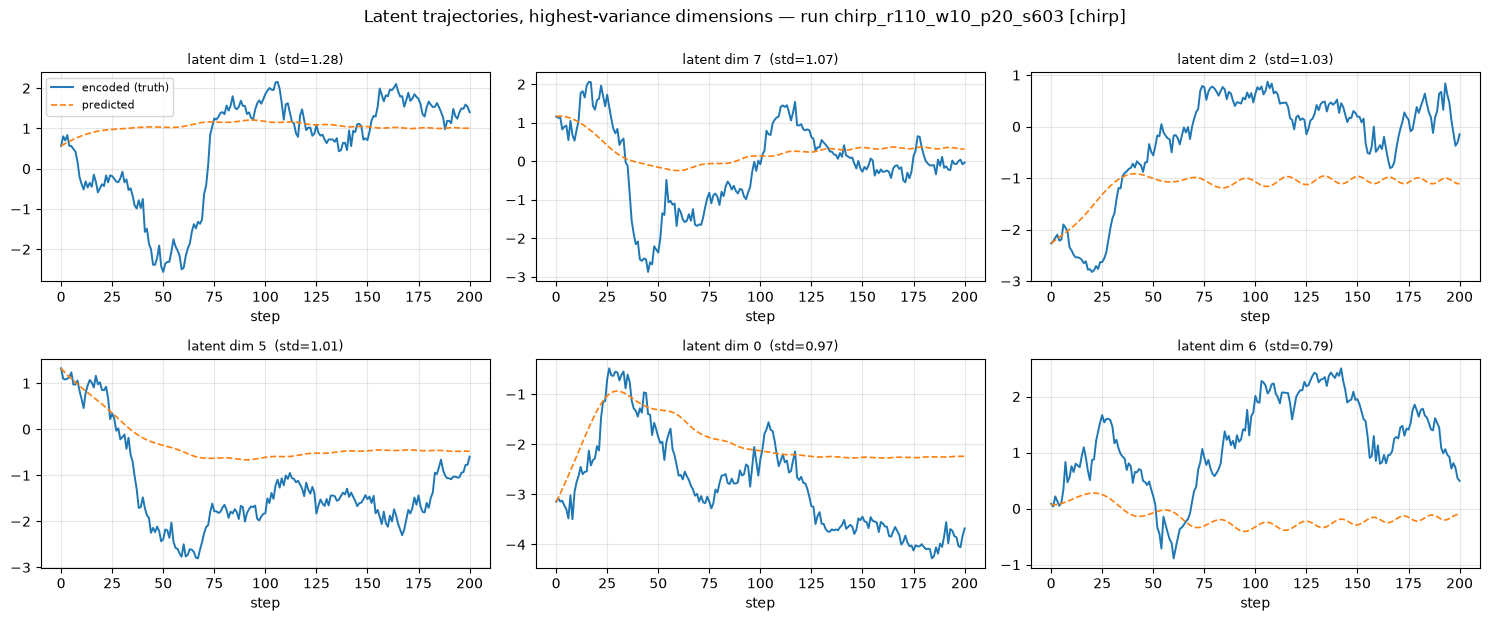

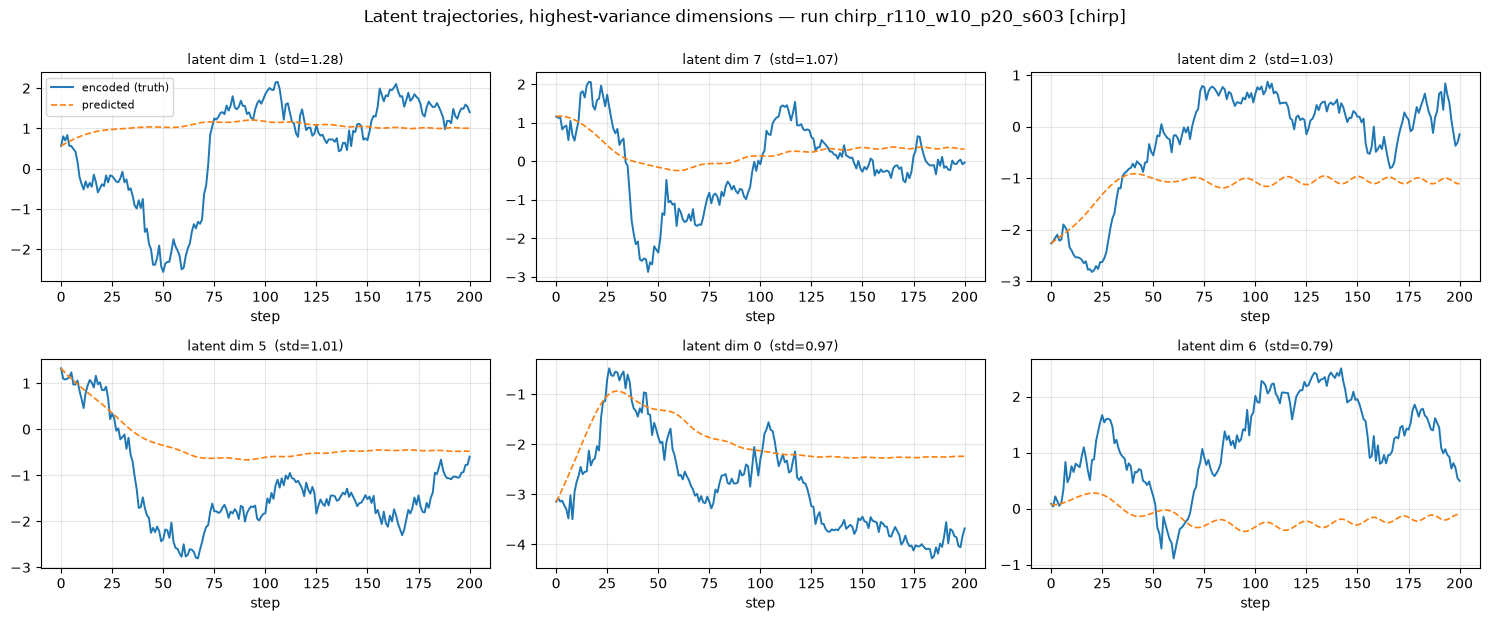

In [8]:
jp.fig_latent_traces(model, val[0], n_dims=6)

## 6. The readout — the decoder's replacement

Held-out R² of the linear map `z -> macros`. For control we care most about
`wolf_count` (MPC cost) and secondarily `rabbit_count` / `grass_frac` (trophic context).


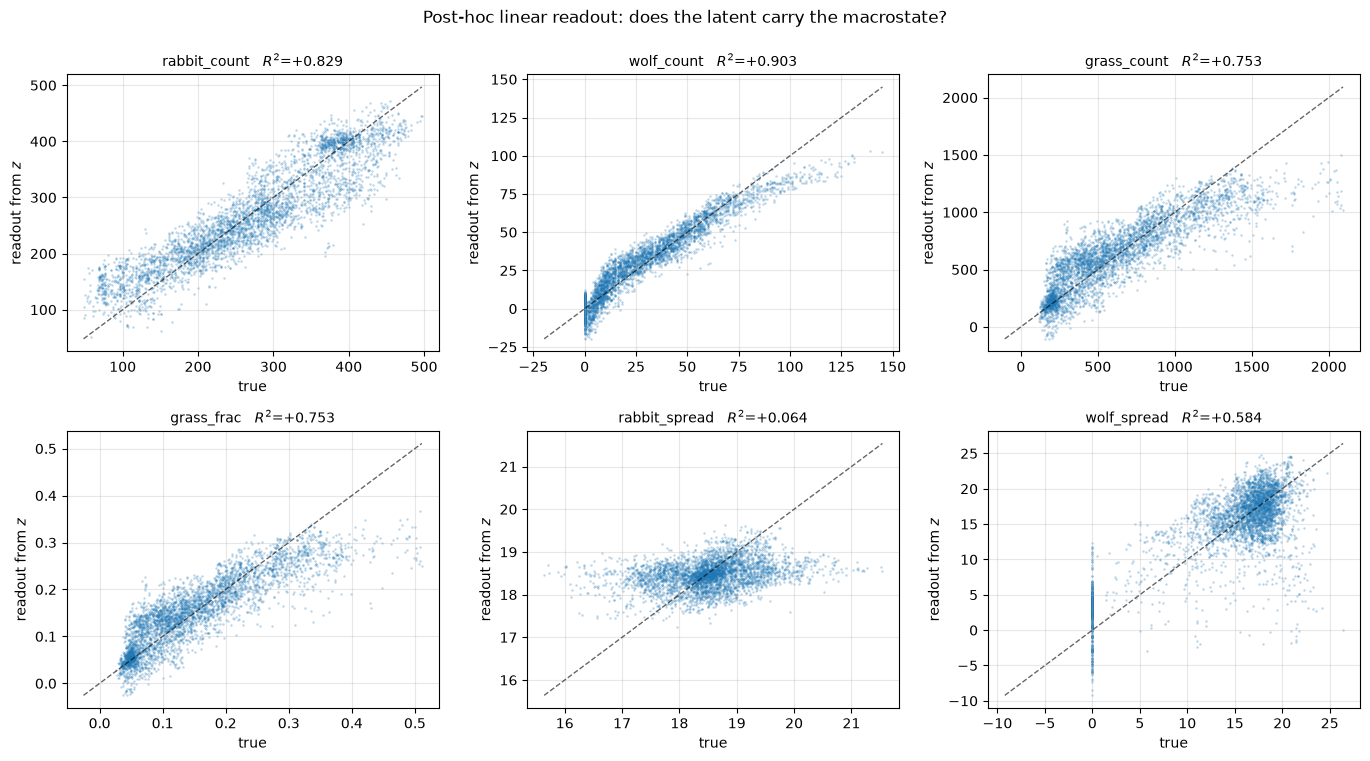

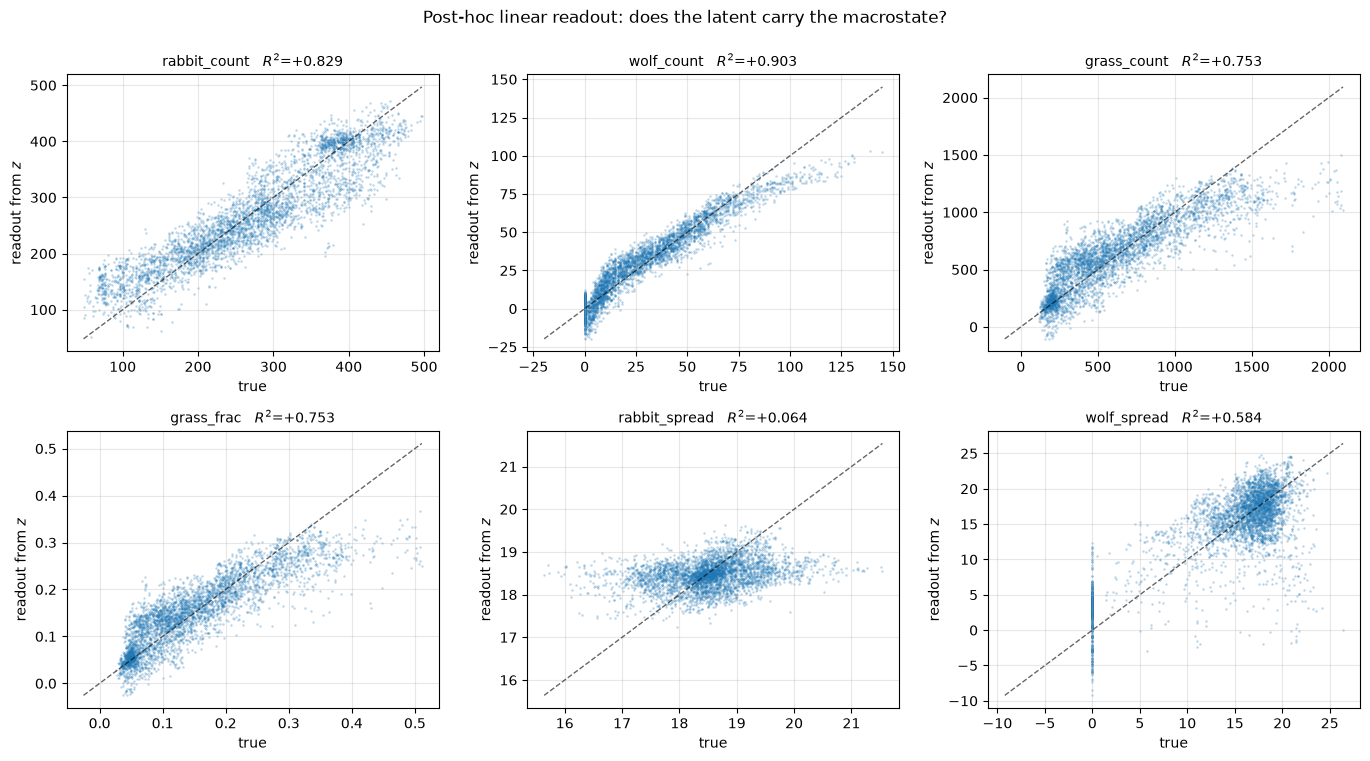

In [9]:
jp.fig_readout_quality(readout, enc, r2_val)

### 6b. Free-running macrostate

Only the first frame is encoded; the rest is predicted from the control sequence and
mapped through the readout onto `wolf_count`.


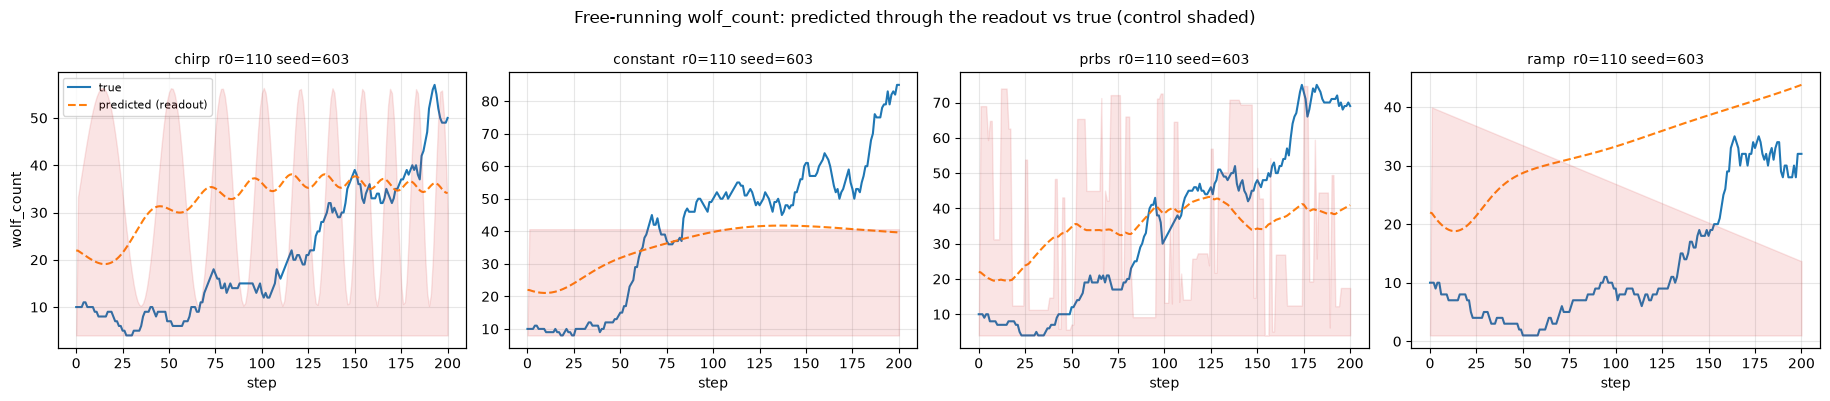

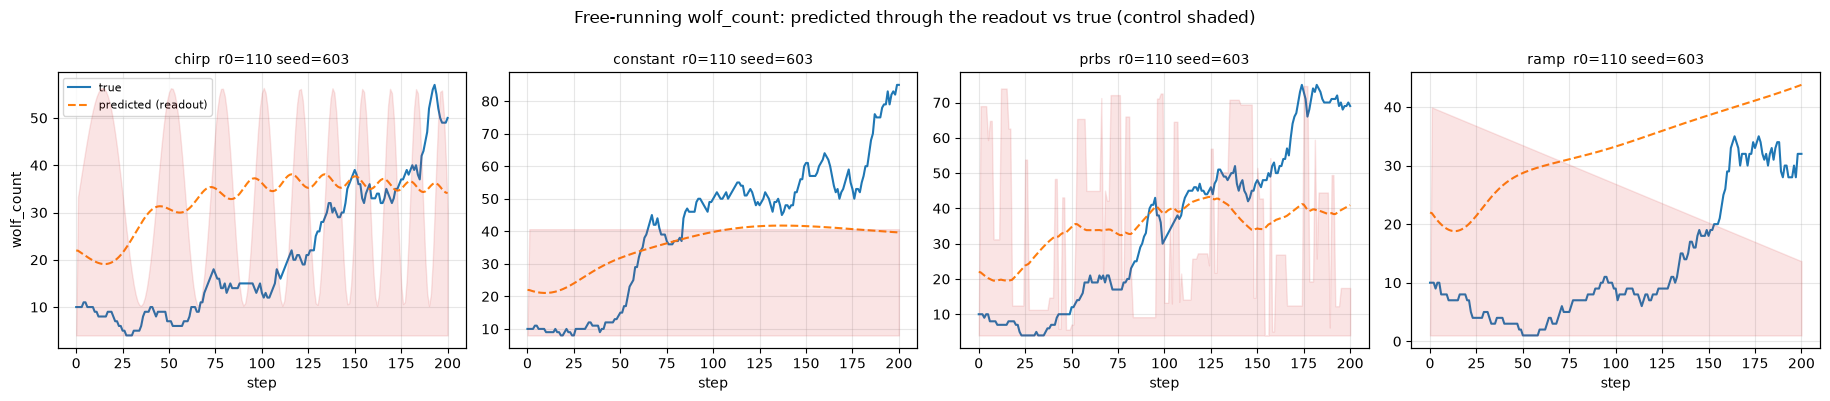

In [10]:
jp.fig_readout_rollout(model, val, readout, n=4, obs_name=CONTROL_OBS)


## 7. Does the model understand the control?

Monotonicity is the requirement, not calibration. More wolf culling must predict fewer
wolves. A planner survives wrong magnitudes; it cannot survive a scrambled ordering.


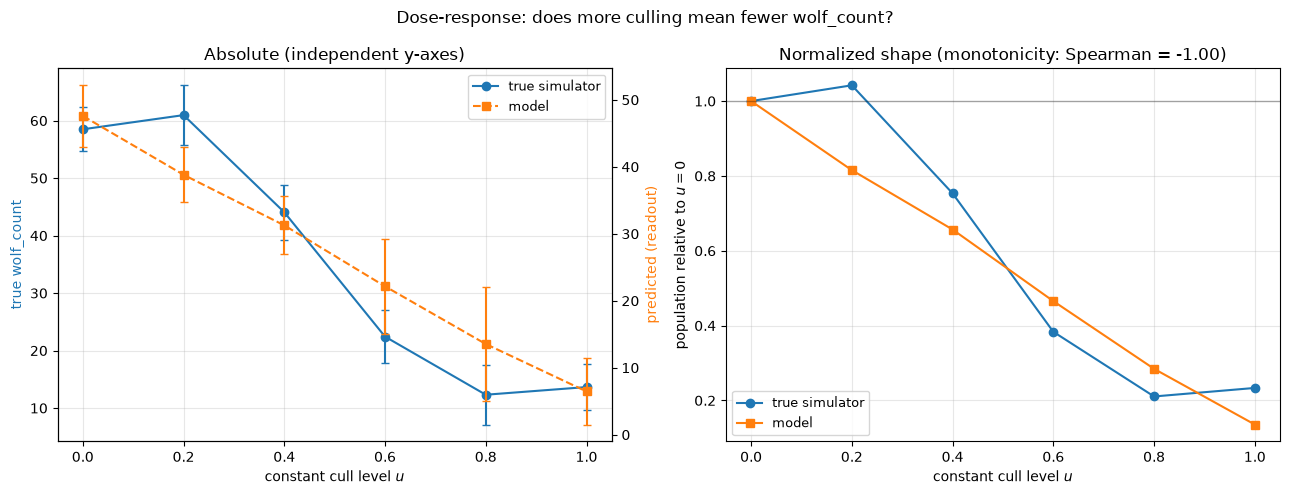

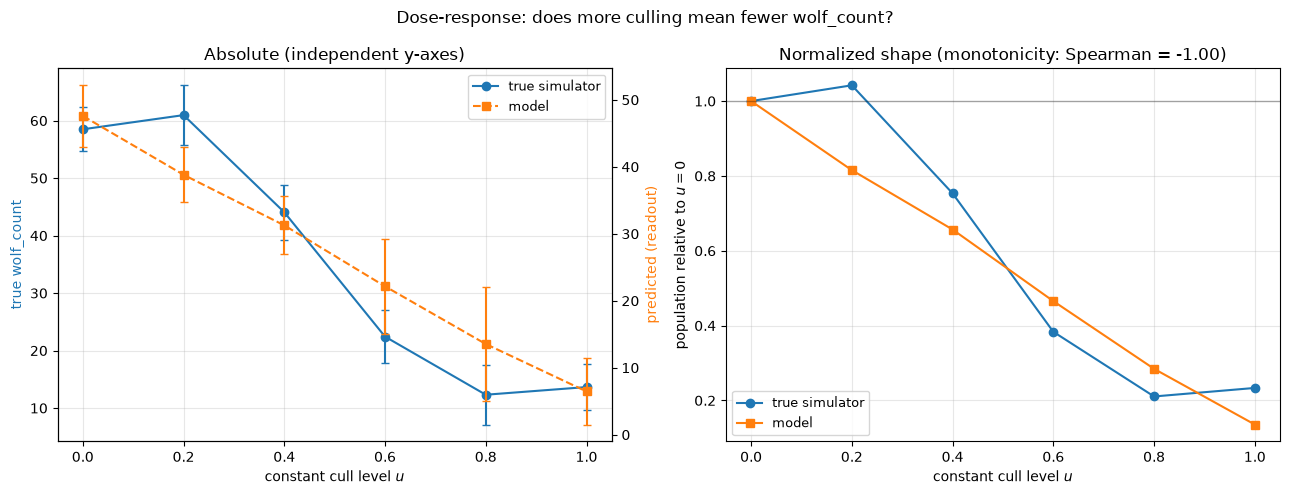

In [11]:
jp.fig_dose_response(dose)

### 7b. Step and impulse response

Deviation of predicted `wolf_count` from the uncontrolled latent rollout.


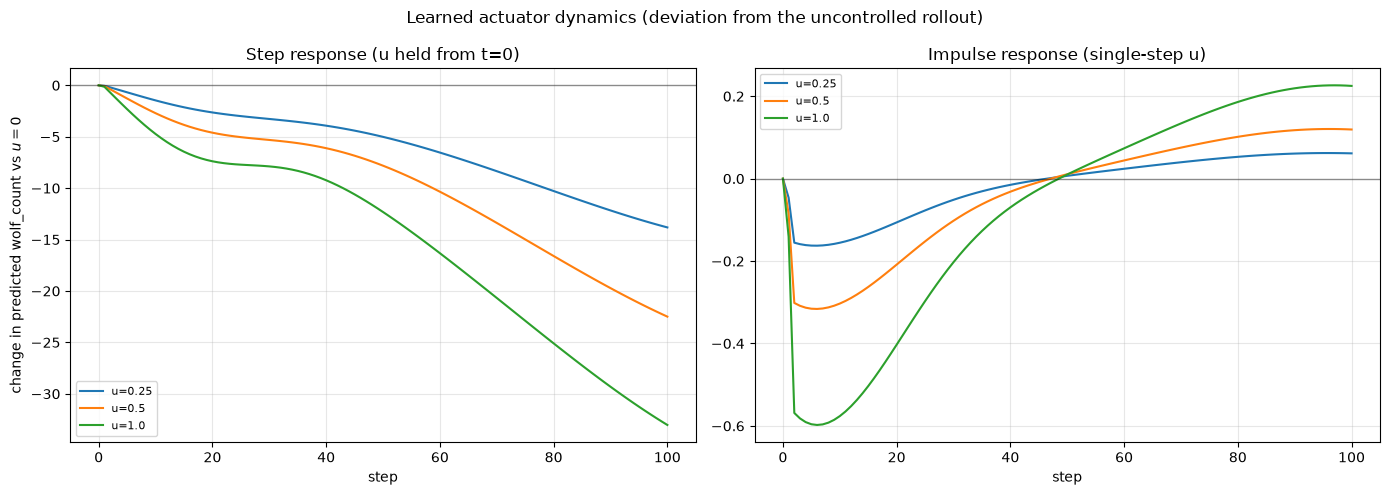

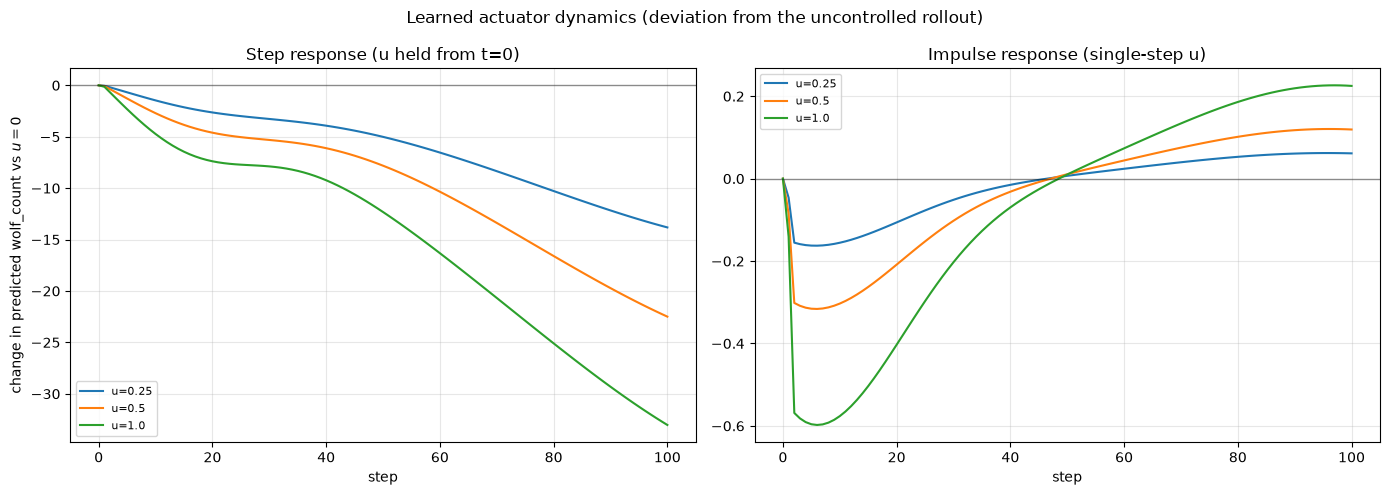

In [12]:
jp.fig_step_response(model, enc["z"][0, 0], readout, steps=100, obs_name=CONTROL_OBS)


## 8. Closed-loop MPC against the true wolf ABM

Encode the current frame, plan with CEM through the learned predictor, apply the first
action to the **true wolf simulator**, and repeat.

The target is midway between the uncontrolled and maximum-cull endpoints of
`wolf_count` so it is reachable by construction. This cell is the slowest in the
notebook; lower `MPC_STEPS` or `n_samples` if you are iterating.


uncontrolled end 60, full-cull end 10
target = 35 wolves
MPC control_cost (u^2 penalty) = 1.0
tracking RMSE 14.1, final error +2.0, mean |u| 0.555


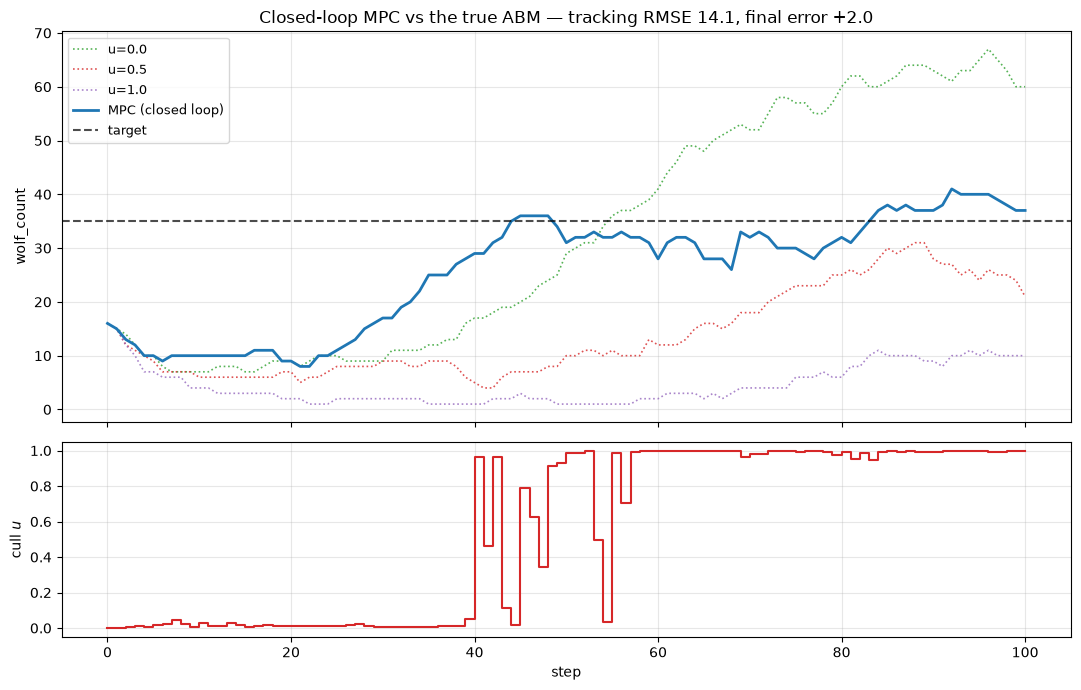

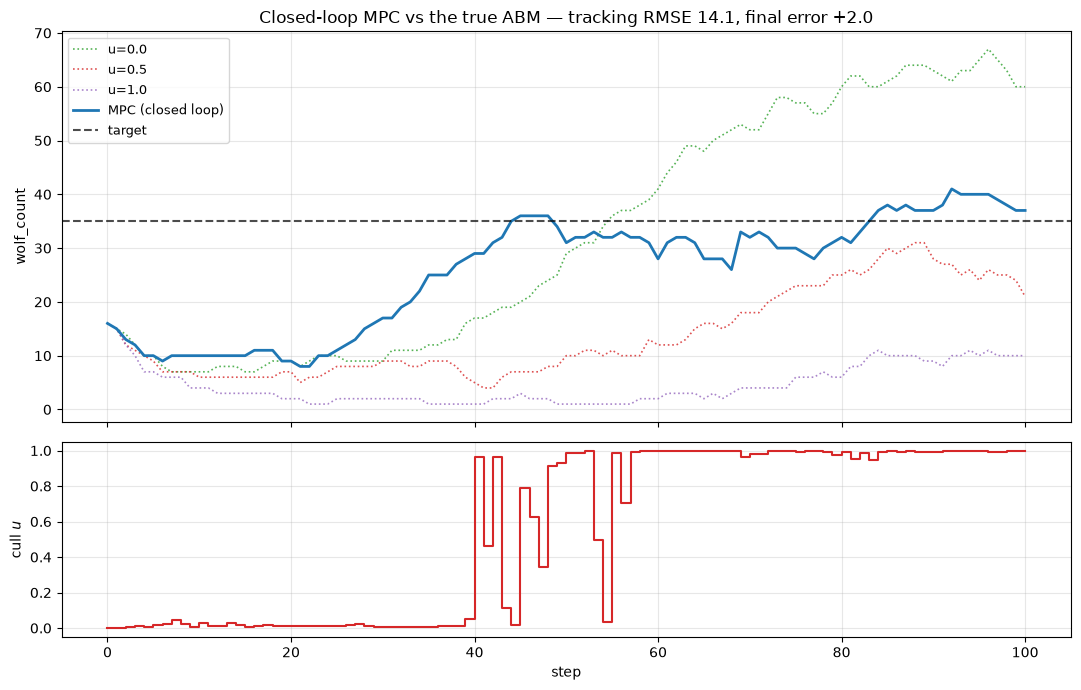

In [13]:
from jepa_control.control import MPCConfig, baseline_rollouts, closed_loop

MPC_STEPS = 100
MPC_CFG = MPCConfig(
    plan_horizon=SCORE_HORIZON,
    n_samples=256,
    n_iters=4,
    control_cost=MPC_CONTROL_COST,
)

base = baseline_rollouts(
    obs_name=CONTROL_OBS,
    abm=ABM,
    cfg=ABM_CFG,
    steps=MPC_STEPS,
    levels=(0.0, 0.5, 1.0),
    initial_rabbits=INITIAL_RABBITS,
    initial_wolves=INITIAL_WOLVES,
    seed=0,
)
TARGET = float(0.5 * (base["u=0.0"][-1] + base["u=1.0"][-1]))
print(f"uncontrolled end {base['u=0.0'][-1]:.0f}, full-cull end {base['u=1.0'][-1]:.0f}")
print(f"target = {TARGET:.0f} wolves")
print(f"MPC control_cost (u^2 penalty) = {MPC_CONTROL_COST}")

loop = closed_loop(
    model,
    readout,
    TARGET,
    obs_name=CONTROL_OBS,
    abm=ABM,
    cfg=ABM_CFG,
    steps=MPC_STEPS,
    initial_rabbits=INITIAL_RABBITS,
    initial_wolves=INITIAL_WOLVES,
    seed=0,
    mpc=MPC_CFG,
)
print(
    f"tracking RMSE {loop['tracking_rmse']:.1f}, "
    f"final error {loop['final_error']:+.1f}, "
    f"mean |u| {loop['control'][1:].mean():.3f}"
)
jp.fig_closed_loop(loop, base)


## 9. Held-out test split

Same scorecard ingredients on the untouched test split.


In [14]:
enc_test = ev.encode_all(model, test)
r2_test = ev.readout_r2(readout, enc_test)
skill_test = ev.readout_rollout_skill(model, enc_test, readout, obs_name=CONTROL_OBS)
herr_test = ev.horizon_errors(model, enc_test, fitted)
pca_test = ev.latent_pca(enc_test)
probe_test = ev.linear_probe(model, probe_train, test)
dose_test = ev.dose_response(
    model,
    readout,
    obs_name=CONTROL_OBS,
    abm=ABM,
    cfg=ABM_CFG,
    steps=100,
    seeds=(10, 11, 12),
    initial_rabbits=INITIAL_RABBITS,
    initial_wolves=INITIAL_WOLVES,
)

print("TEST scorecard")
print(ev.format_scorecard(ev.scorecard(
    model=model, herr=herr_test, probe=probe_test, pca=pca_test, readout_r2_test=r2_test,
    rollout_skill=skill_test, dose=dose_test, fitted=fitted, horizon=SCORE_HORIZON,
    primary_obs=CONTROL_OBS,
)))


TEST scorecard
metric                                 value  status  note
--------------------------------------------------------------
prediction skill @ h=20               +0.520  [ ok ]  vs +0.203 for the persistence baseline
beats persistence?                       yes  [ ok ]  a model that loses to a frozen latent learned no dynamics
no collapse (dims in use)            7.3 / 8  [ ok ]  participation ratio; 8 components cover 95%
wolf_count readout R^2                +0.901  [ ok ]  held-out; this is what the MPC cost is written in
control legible in latent             +0.086  [FAIL]  R^2 predicting the applied u from z alone
macrostate rollout corr               +0.497  [FAIL]  free-running wolf_count; RMSE 22.6
dose-response monotonic                -1.00  [ ok ]  -1 means more culling reliably predicts fewer wolf_count
ls_linear skill (diagnostic)          +0.563  [ -- ]  post-hoc LS operator skill; one-step R^2 = 0.975. With predictor='linear', full should match this; a gap m

## 10. Reading the result

- **Prediction skill ≪ persistence** → dynamics undertrained (classic failure mode when
  `A≈I`, `B≈0`).
- **`wolf_count` readout R² high, skill low** → encoder saw the population, predictor did
  not learn the actuator.
- **Dose Spearman near −1** → ordering is right for wolf cull; MPC can at least push the
  right way.
- Closed-loop RMSE should beat the best constant cull in the baseline band.


## 11. Baseline: fit a predator–prey ODE and control with it

Skip images: fit a discrete trophic ODE on `(rabbit_count, wolf_count, grass_frac)` with
delayed wolf culling, and run the **same CEM MPC** with oracle macros each step.

$$
\begin{aligned}
R' &= R + R\,(\alpha G - \mu_R - \pi W) \\
W' &= W + W\,(\gamma R - \mu_W - \kappa u - \lambda u_{\mathrm{prev}}) \\
G' &= G + r(1-G) - \beta R G
\end{aligned}
$$

Parameters are least-squares fits on one-step deltas from the train probe set. Closed
loop still acts on the true wolf ABM. If JEPA cannot match this under the same target /
horizon / seed as section 8, the latent controller is not yet earning its complexity.


fitted predator–prey ODE
  growth=0.1414  death_r=0.0024  predation=0.000532
  conversion=0.000309  death_w=0.0567
  cull_now=0.0629  cull_lag=-0.0218
  regrow=0.0047  consume=0.000154
  one-step R²  rabbit=+0.343  wolf=+0.099  grass=+0.162

val free-rollout @ h=20: ODE skill -1.545  (persistence -2.262)

ODE MPC  tracking RMSE 14.1, final error +1.0
JEPA MPC tracking RMSE 14.1, final error +2.0
JEPA − ODE RMSE: -0.0  (JEPA better)


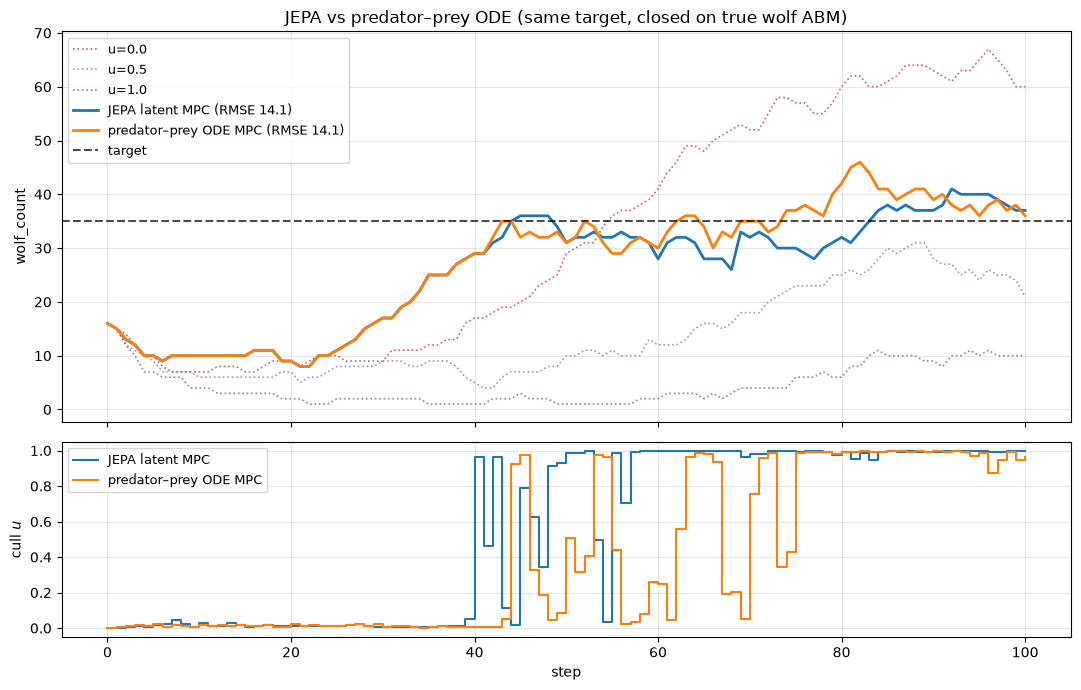

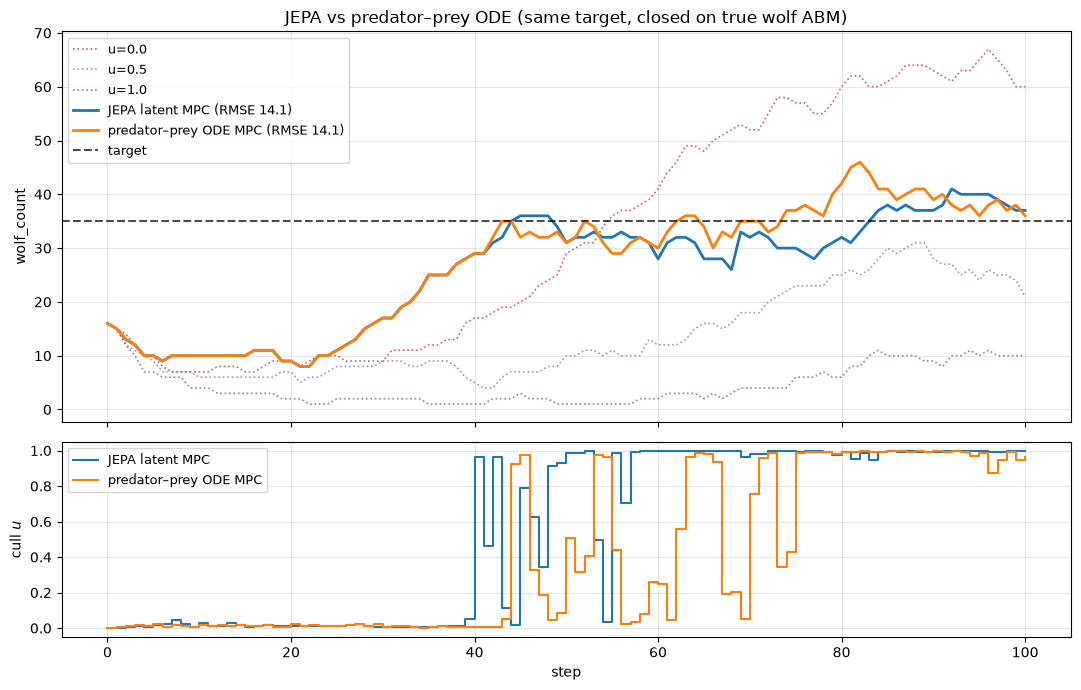

In [15]:
from jepa_control.ode_baseline import (
    closed_loop_predator_prey_ode,
    fit_predator_prey_ode,
    predator_prey_prediction_skill,
)
from jepa_control.plots import fig_controller_compare

ode_train = probe_train
ode = fit_predator_prey_ode(ode_train)
print("fitted predator–prey ODE")
print(f"  growth={ode.growth:.4f}  death_r={ode.death_r:.4f}  predation={ode.predation:.6f}")
print(f"  conversion={ode.conversion:.6f}  death_w={ode.death_w:.4f}")
print(f"  cull_now={ode.cull_now:.4f}  cull_lag={ode.cull_lag:.4f}")
print(f"  regrow={ode.regrow:.4f}  consume={ode.consume:.6f}")
print(f"  one-step R²  rabbit={ode.rabbit_one_step_r2:+.3f}  "
      f"wolf={ode.wolf_one_step_r2:+.3f}  grass={ode.grass_one_step_r2:+.3f}")

ode_skill = predator_prey_prediction_skill(
    val, ode, horizon=SCORE_HORIZON, obs_name=CONTROL_OBS
)
print(f"\nval free-rollout @ h={SCORE_HORIZON}: "
      f"ODE skill {ode_skill['skill']:+.3f}  "
      f"(persistence {ode_skill['skill_persistence']:+.3f})")

ode_loop = closed_loop_predator_prey_ode(
    ode,
    TARGET,
    obs_name=CONTROL_OBS,
    cfg=ABM_CFG,
    steps=MPC_STEPS,
    initial_rabbits=INITIAL_RABBITS,
    initial_wolves=INITIAL_WOLVES,
    seed=0,
    mpc=MPC_CFG,
)
print(f"\nODE MPC  tracking RMSE {ode_loop['tracking_rmse']:.1f}, "
      f"final error {ode_loop['final_error']:+.1f}")
print(f"JEPA MPC tracking RMSE {loop['tracking_rmse']:.1f}, "
      f"final error {loop['final_error']:+.1f}")
delta = loop["tracking_rmse"] - ode_loop["tracking_rmse"]
print(
    f"JEPA − ODE RMSE: {delta:+.1f}  "
    f"({'JEPA better' if delta < 0 else 'ODE better' if delta > 0 else 'tie'})"
)

fig_controller_compare(
    {"JEPA latent MPC": loop, "predator–prey ODE MPC": ode_loop},
    base,
    title="JEPA vs predator–prey ODE (same target, closed on true wolf ABM)",
)
